# 07 — Test-set comparison: quantum vs classical (M7)

> **Inputs:** Z and R only (the brief's inputs). **Quantum:** local simulators only (exact statevectors; finite shots
> drawn exactly as an ideal device returns them; the FakeFez noise model on Aer). **Nothing is sent to IBM hardware.**

This notebook presents one **full test run** of `scripts/final_eval.py` (by default the latest run in
`results/test_runs.csv` with all four sections; set `QM9DIPOLE_TEST_RUN` to show another), then any later, partial
runs (section 8: post-hoc changes, labeled as such). It trains nothing: the script fitted every model on the saved training
sets, tuned each one by cross-validation inside its own training set, and scored it on

- `test_familiar` (5,484 molecules whose formulas appear in the training pool) and `test_unseen` (16,818 molecules
  from 93 formulas held out of every training and development set): the **test sets**;
- `dev` and `dev_unseen`, as in the development notebooks: a check that this run reproduces notebooks 04 and 06;
- `test_familiar_q` (80) and `test_unseen_q` (370): the small quantum test subsets, for finite shots and noise.

**How the test sets are used.** The team may look at a test run, change models or settings and run again
(CLAUDE.md rule 2). Each run is logged with its commit and a note saying what changed, and the writeup reports how
many test runs there were. Inside a run, nothing is chosen on a test set: the headline quantum model and the best
quantum-comparable classical model are chosen by cross-validation, and the best accurate classical model (Track A) at
each size by its `dev` score, the rules of notebook 06.

In [1]:
# Environment check: stops here, with setup instructions, unless this kernel is the project
# environment (README.md, "Setup"). Version differences from requirements.txt only warn.
try:
    from qm9dipole.provenance import check_environment
except ModuleNotFoundError as e:
    raise RuntimeError(
        "The qm9dipole package is not installed in this kernel's environment. Follow "
        "README.md (Setup), then select that environment as the notebook kernel."
    ) from e

print(check_environment())

environment OK: Python 3.12.14, 16 pinned packages checked, 0 differ; package and notebook are in the same checkout


In [2]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import FixedLocator, NullFormatter

from qm9dipole import REPO_ROOT
from qm9dipole.cost import circuits_needed, qpu_seconds
from qm9dipole.data import PROCESSED_DIR
from qm9dipole.final import RUN_LOG
from qm9dipole.plots import AXIS, INK_SECONDARY, MODEL_LABELS, MUTED, model_style, use_style
from qm9dipole.provenance import RESULTS_DIR, save_result

# Development switch: QM9DIPOLE_DRY_RUN=1 presents the dry run (scripts/final_eval.py --dry-run), which scores the
# development sets only, under the test sets' names in the tables. Unset to present a test run.
DRY = os.environ.get("QM9DIPOLE_DRY_RUN") == "1"
use_style()
FIG_DIR = REPO_ROOT / "figures"
if DRY:
    SRC, TAG, RUN = PROCESSED_DIR / "final_eval_dry_run", "dryrun", 0
    TEST, Q_SETS = ["dev", "dev_unseen"], ["dev_q", "dev_unseen_q"]
    OUT_DIR, FIG_OUT = SRC, SRC
else:
    runs = pd.read_csv(RUN_LOG)
    display(runs.set_index("run").style.set_caption("test runs so far (results/test_runs.csv)"))
    full = runs[runs["sections"].str.split(",").map(len) == 4]
    RUN = int(os.environ.get("QM9DIPOLE_TEST_RUN", full["run"].max()))
    SRC, TAG = RESULTS_DIR, f"test_run{RUN:02d}"
    TEST, Q_SETS = ["test_familiar", "test_unseen"], ["test_familiar_q", "test_unseen_q"]
    OUT_DIR, FIG_OUT = RESULTS_DIR, FIG_DIR
DEV_OF = dict(zip(TEST, ["dev", "dev_unseen"]))
# later test runs of scripts/final_eval.py (hardware runs are presented in section 9)
LATER = [] if DRY else [int(r) for r, sec in zip(runs["run"], runs["sections"]) if r > RUN and "quantum" in sec.split(",")]


def load(section):
    return pd.read_csv(SRC / f"{TAG}_{section}.csv"), json.loads((SRC / f"{TAG}_{section}.meta.json").read_text())


(quantum, meta_q), (track_a, meta_a), (shots, meta_s), (noise, meta_n) = (load(s) for s in ("quantum", "track_a", "shots", "noise"))
quantum["inputs"] = quantum["inputs"].fillna("—")
SIZES = sorted(quantum["n_train"].unique())
SIZES_A = sorted(track_a["n_train"].unique())
FULL = SIZES_A[-1]
SEEDS = sorted(quantum["seed"].unique())
QMODELS = ["qkrr", "qkrr_ry", "qkrr_ryrz", "qkrr_product", "pqk", "qridge"]
CONTROLS = ["qkrr_product"]  # a classical kernel in quantum form: reported, never the headline
CLASSICAL_B = ["ridge", "rbf_krr", "rf"]
RED = "pls10"
print(f"{TAG}: commit {meta_q['git_hash'][:10]}, note: {meta_q['note']}")
print(f"evaluation sets: {meta_q['eval_sets']}")
print(f"quantum section: N {SIZES} × seeds {SEEDS}; Track A: N {SIZES_A} (seeds {sorted(track_a['seed'].unique())})")

,started,finished,commit,config_hash,sections,smoke,note
run,,,,,,,
1,2026-10-07 15:35,2026-10-07 19:45,cc6fab3,d91d58827294,"quantum,track_a,shots,noise",False,"run 1: the models and settings of the development notebooks (explore_04, 06, 07), unchanged"
2,2026-10-07 19:47,2026-10-07 20:18,89e6b62,5f687d286079,quantum,False,"run 2 (post-hoc, after run 1): shot-aware quantum kernels (fidelity and projected), tuned, fit and evaluated with 100 / 1,000 / 10,000 shots per circuit; quantum section only; everything else as run 1"
3,2026-10-07 20:20,2026-10-07 20:20,89e6b62,e6f39ca13e27,hardware:FakeQuebec,False,"local noise model run of pqk, qridge, kernel on FakeQuebec: S_(0,100), 30 molecules per quantum test subset, 1,000 shots; settings from test_run01_quantum.csv"
4,2026-10-07 19:25,2026-10-07 20:53,1355057,be90f21432c3,hardware:ibm_quebec,False,"device run of qridge on ibm_quebec: S_(0,100), 30 molecules per quantum test subset, 1,000 shots; settings from test_run01_quantum.csv"


test_run01: commit cc6fab3b16, note: run 1: the models and settings of the development notebooks (explore_04, 06, 07), unchanged
evaluation sets: {'test_familiar': 5484, 'test_unseen': 16818, 'dev': 5000, 'dev_unseen': 4183, 'test_familiar_q': 80, 'test_unseen_q': 370}
quantum section: N [np.int64(100), np.int64(300), np.int64(1000)] × seeds [np.int64(0), np.int64(1), np.int64(2)]; Track A: N [np.int64(100), np.int64(300), np.int64(1000), np.int64(3000), np.int64(10000), np.int64(99198)] (seeds [np.int64(0), np.int64(1), np.int64(2)])


## 1. Does this run reproduce the development notebooks?

Same code, training sets, folds and seeds as notebooks 04 and 06, so the `dev` and `dev_unseen` scores of this run
should match theirs. A mismatch would mean the script built a model differently from the notebook it is meant to
reproduce, and its test numbers would not be the models the development work studied.

In [3]:
def ref_rows():
    b = pd.read_csv(RESULTS_DIR / "explore04_track_b.csv").rename(columns={"features": "inputs"})
    m6 = pd.read_csv(RESULTS_DIR / "explore06_main.csv").rename(columns={"features": "inputs"})
    m6.loc[m6["model"] == "mean", "inputs"] = "—"
    i6 = pd.read_csv(RESULTS_DIR / "explore06_inputs.csv").rename(columns={"features": "inputs"})
    keys = ["model", "inputs", "seed", "n_train", "eval_set"]
    ref = pd.concat([m6, b, i6], ignore_index=True)
    ref["inputs"] = ref["inputs"].fillna("—")
    return ref.drop_duplicates(keys).set_index(keys)["mae_D"]


keys = ["model", "inputs", "seed", "n_train", "eval_set"]
ours = quantum[quantum["eval_set"].isin(["dev", "dev_unseen"])].set_index(keys)["mae_D"]
ref = ref_rows()
common = ours.index.intersection(ref.index)
gap_q = (ours.loc[common] - ref.loc[common]).abs().groupby(level=["model", "inputs"]).agg(["count", "max"])
ka = ["model", "seed", "n_train", "eval_set"]
ours_a = track_a.set_index(ka)["mae_D"]
ref_a = pd.read_csv(RESULTS_DIR / "explore04_track_a.csv").set_index(ka)["mae_D"]
common_a = ours_a.index.intersection(ref_a.index)
gap_a = (ours_a.loc[common_a] - ref_a.loc[common_a]).abs().groupby(level="model").agg(["count", "max"])
gap_a.index = pd.MultiIndex.from_arrays([gap_a.index, ["Track A"] * len(gap_a)], names=["model", "inputs"])
gaps = pd.concat([gap_q, gap_a]).rename(columns={"count": "rows compared", "max": "max |Δ MAE| (D)"})
display(gaps.style.format({"max |Δ MAE| (D)": "{:.1e}"}).set_caption(
    "development-set MAE of this run minus the development notebooks (04, 06), same model, inputs, seed and N"))
print(f"{len(common) + len(common_a)} of {len(ours) + len(ours_a)} development rows have a reference; "
      f"largest difference {gaps['max |Δ MAE| (D)'].max():.1e} D")

464 of 622 development rows have a reference; largest difference 0.0e+00 D


## 2. Headline: quantum vs classical on the test sets

The rules of notebook 06, applied unchanged:
- **Headline quantum model:** the quantum configuration on PLS(10) inputs (product-state control excluded) with the
  lowest 5-fold CV MAE at N = 1000, averaged over seeds. CV happens inside the training sets, so this choice does
  not look at any evaluation set.
- **Matched classical:** RBF kernel ridge on the same 10 PLS inputs with the same tuning budget; the paired
  difference (same training set, same test molecules) is the fairest single number.
- **Best Track B:** the quantum-comparable classical model (any of ridge, RBF kernel ridge or random forest on any
  input set) with the lowest CV MAE at each N.
- **Best Track A:** the most accurate classical pipeline at each N (lowest `dev` MAE, the rule of notebook 04), and at
  the full training pool.

In [4]:
def per_seed(df, ev, cols=("mae_D", "rmse_D")):
    return df[df["eval_set"] == ev].set_index(["seed", "n_train"])[list(cols)]


cv = quantum[quantum["eval_set"] == quantum["eval_set"].iloc[0]].groupby(["model", "inputs", "n_train"])["cv_mae_D"].mean()
cand = cv.xs((RED, max(SIZES)), level=("inputs", "n_train"))
cand = cand[[m for m in QMODELS if m not in CONTROLS and m in cand.index]]
HEAD = cand.idxmin()
cv_b = cv.loc[CLASSICAL_B]
BEST_B = {n: cv_b.xs(n, level="n_train").idxmin() for n in SIZES}  # (model, inputs) by CV at each N
dev_a = track_a[track_a["eval_set"] == "dev"].groupby(["model", "n_train"])["mae_D"].mean()
dev_a = dev_a.drop("mean", level="model")
BEST_A = {n: dev_a.xs(n, level="n_train").idxmin() for n in SIZES_A}
print(f"headline quantum model (CV at N = {max(SIZES)}): {MODEL_LABELS[HEAD]} (CV MAE {cand.min():.3f} D)")
print("best Track B by CV: " + ", ".join(f"N = {n}: {MODEL_LABELS[m]} on {i}" for n, (m, i) in BEST_B.items()))
print("best Track A by dev: " + ", ".join(f"N = {n:,}: {MODEL_LABELS[m]}" for n, m in BEST_A.items()))


def sel(model, inputs=None, frame=None):
    frame = quantum if frame is None else frame
    s = frame[frame["model"] == model]
    return s if inputs is None else s[s["inputs"] == inputs]


rows = []
for ev in TEST:
    q = per_seed(sel(HEAD, RED), ev)
    r = per_seed(sel("rbf_krr", RED), ev)
    mean_b = per_seed(sel("mean"), ev)
    for n in SIZES:
        d = (q.xs(n, level="n_train")["mae_D"] - r.xs(n, level="n_train")["mae_D"])
        mb, ib = BEST_B[n]
        b = per_seed(sel(mb, ib), ev).xs(n, level="n_train")
        a = per_seed(track_a[track_a["model"] == BEST_A[n]], ev).xs(n, level="n_train")
        af = per_seed(track_a[track_a["model"] == BEST_A[FULL]], ev).xs(FULL, level="n_train")
        rows.append({"eval_set": ev, "N": n, "quantum model": MODEL_LABELS[HEAD],
                     "quantum MAE": q.xs(n, level="n_train")["mae_D"].mean(), "quantum MAE sd": q.xs(n, level="n_train")["mae_D"].std(),
                     "quantum RMSE": q.xs(n, level="n_train")["rmse_D"].mean(),
                     "matched RBF KRR MAE": r.xs(n, level="n_train")["mae_D"].mean(),
                     "matched RBF KRR RMSE": r.xs(n, level="n_train")["rmse_D"].mean(),
                     "paired Δ MAE (quantum − RBF)": d.mean(), "paired Δ sd": d.std(),
                     "best Track B": f"{MODEL_LABELS[mb]} on {ib}", "best Track B MAE": b["mae_D"].mean(),
                     "best Track B RMSE": b["rmse_D"].mean(),
                     "best Track A": MODEL_LABELS[BEST_A[n]], "best Track A MAE": a["mae_D"].mean(),
                     "best Track A RMSE": a["rmse_D"].mean(),
                     f"best Track A, N = {FULL:,} MAE": af["mae_D"].mean(),
                     "mean baseline MAE": mean_b.xs(n, level="n_train")["mae_D"].mean()})
headline = pd.DataFrame(rows)
_ = save_result(headline, f"{TAG}_headline", out_dir=OUT_DIR, run=RUN, head=HEAD,
                best_track_b={str(n): list(v) for n, v in BEST_B.items()}, best_track_a={str(n): v for n, v in BEST_A.items()},
                label=("dry run on development sets" if DRY else "test-set evaluation") + "; Z, R only; mean over seeds")
num = [c for c in headline.columns if headline[c].dtype.kind == "f"]
display(headline.set_index(["eval_set", "N"]).style.format({c: "{:.3f}" for c in num}).set_caption(
    "MAE and RMSE in debye, mean over seeds (sd: across seeds); paired Δ < 0 means the quantum model is better"))

headline quantum model (CV at N = 1000): quantum kernel ridge (ZZ map) (CV MAE 0.498 D)
best Track B by CV: N = 100: RBF kernel ridge on all_legal, N = 300: RBF kernel ridge on all_legal, N = 1000: RBF kernel ridge on all_legal
best Track A by dev: N = 100: XGBoost, N = 300: RBF kernel ridge, N = 1,000: charge network, N = 3,000: charge network, N = 10,000: charge network, N = 99,198: charge network


### Every model of the quantum section, on the test sets

In [5]:
def table(frame, ev, metric):
    s = frame[frame["eval_set"] == ev].groupby(["model", "inputs", "n_train"])[metric].agg(["mean", "std"])
    txt = s["mean"].map("{:.3f}".format) + " ± " + s["std"].fillna(0).map("{:.3f}".format)
    t = txt.unstack("n_train")
    order = ["mean", *CLASSICAL_B, *QMODELS]
    t = t.reindex(sorted(t.index, key=lambda k: (order.index(k[0]), k[1])))
    t.index = pd.MultiIndex.from_tuples([(MODEL_LABELS[m], i) for m, i in t.index], names=["model", "inputs"])
    return t


for ev in TEST:
    for metric in ("mae_D", "rmse_D"):
        display(table(quantum, ev, metric).style.set_caption(f"{ev}: {metric[:-2].upper()} (D), mean ± sd over seeds, by N"))

### Learning curves

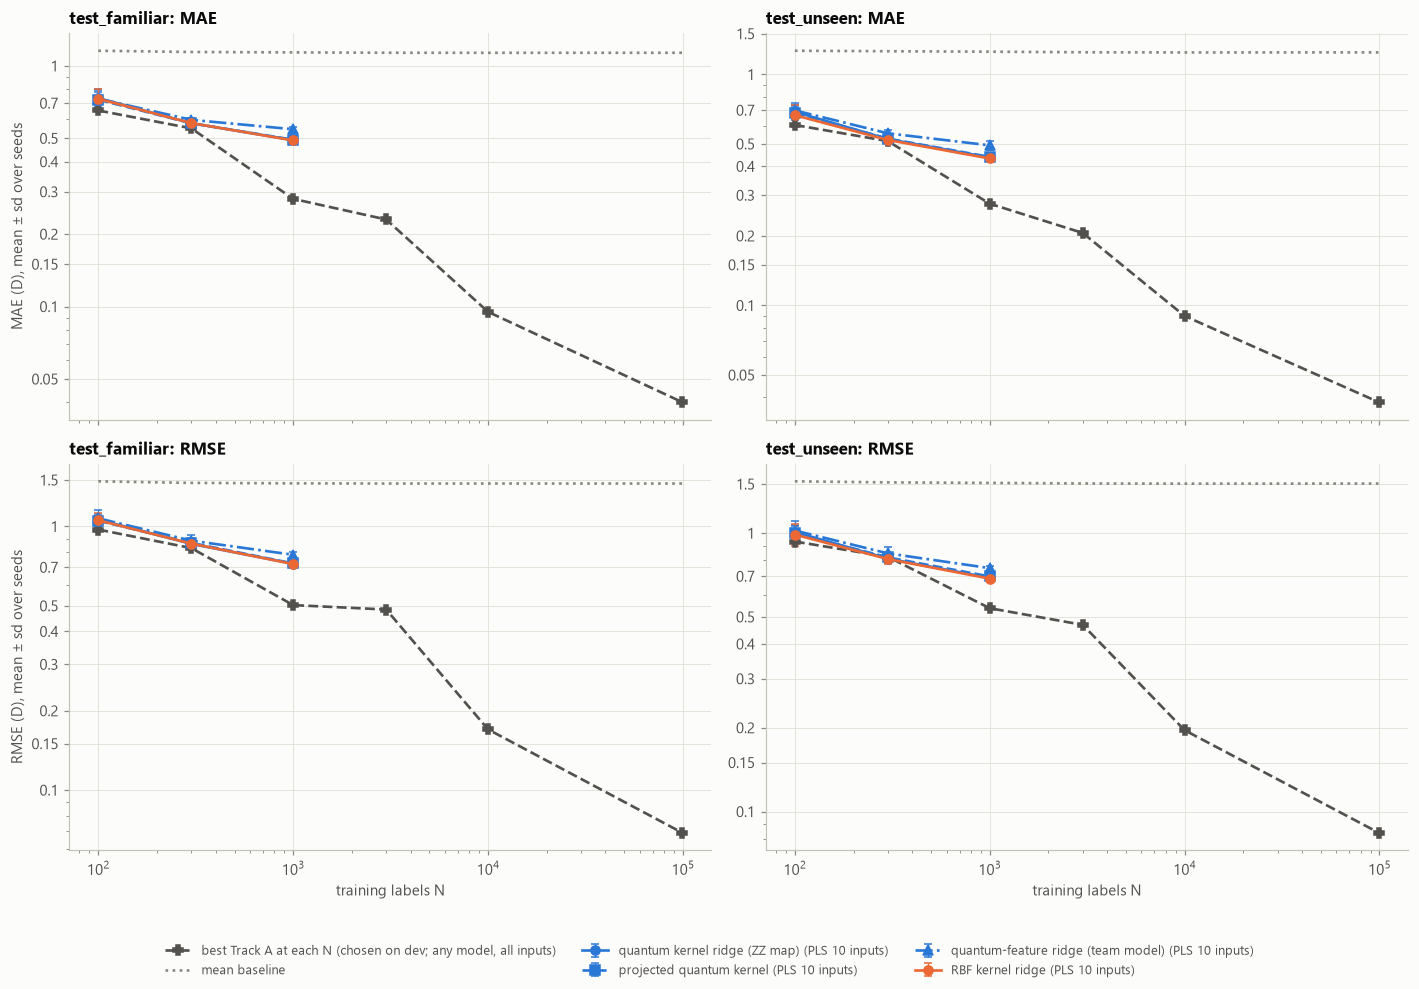

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
SHOW = [(HEAD, RED), ("pqk", RED), ("qridge", RED), ("rbf_krr", RED)]
SHOW = list(dict.fromkeys(SHOW))
for col, ev in enumerate(TEST):
    for row, metric in enumerate(("mae_D", "rmse_D")):
        ax = axes[row, col]
        for m, i in SHOW:
            s = sel(m, i)
            s = s[s["eval_set"] == ev].groupby("n_train")[metric].agg(["mean", "std"])
            ax.errorbar(s.index, s["mean"], yerr=s["std"].fillna(0), capsize=2.5, elinewidth=0.9,
                        label=f"{MODEL_LABELS[m]} (PLS 10 inputs)", **model_style(m))
        best = [track_a[(track_a["model"] == BEST_A[n]) & (track_a["n_train"] == n) & (track_a["eval_set"] == ev)][metric].mean()
                for n in SIZES_A]
        ax.plot(SIZES_A, best, color=INK_SECONDARY, linestyle="--", marker="P",
                label="best Track A at each N (chosen on dev; any model, all inputs)")
        mb = track_a[(track_a["model"] == "mean") & (track_a["eval_set"] == ev)].groupby("n_train")[metric].mean()
        ax.plot(mb.index, mb.values, color=MUTED, linestyle=":", label="mean baseline")
        ax.set(xscale="log", yscale="log", title=f"{ev}: {metric[:-2].upper()}")
        ax.yaxis.set_major_locator(FixedLocator([0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.5, 2.0]))
        ax.yaxis.set_major_formatter(lambda v, _: f"{v:g}")
        ax.yaxis.set_minor_formatter(NullFormatter())
        if col == 0:
            ax.set_ylabel(f"{metric[:-2].upper()} (D), mean ± sd over seeds")
        if row == 1:
            ax.set_xlabel("training labels N")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=8.5, frameon=False)
fig.tight_layout(rect=(0, 0.07, 1, 1))
fig.savefig(FIG_OUT / f"{TAG}_learning_curves.png")
plt.show()

### The most accurate classical models (Track A) to the full training pool

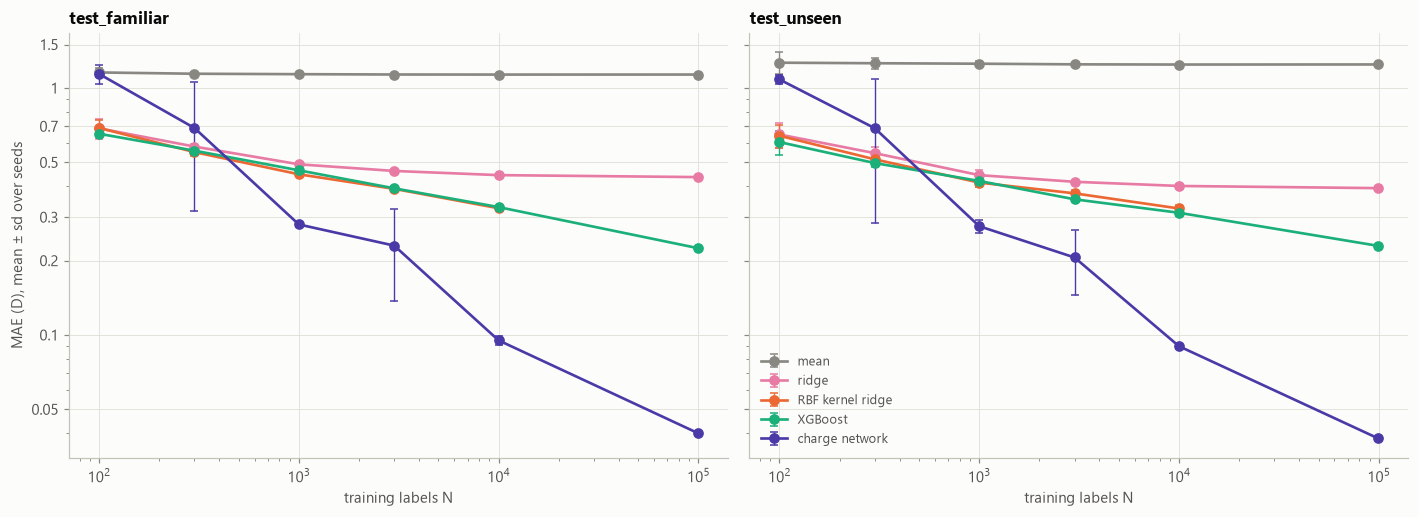

In [7]:
TA_MODELS = [m for m in ["mean", "ridge", "rbf_krr", "xgb", "charge_net"] if m in set(track_a["model"])]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, ev in zip(axes, TEST):
    for m in TA_MODELS:
        s = track_a[(track_a["model"] == m) & (track_a["eval_set"] == ev)].groupby("n_train")["mae_D"].agg(["mean", "std"])
        ax.errorbar(s.index, s["mean"], yerr=s["std"].fillna(0), capsize=2.5, elinewidth=0.9, label=MODEL_LABELS[m],
                    **model_style(m))
    ax.set(xscale="log", yscale="log", xlabel="training labels N", title=ev)
    ax.yaxis.set_major_locator(FixedLocator([0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5]))
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:g}")
    ax.yaxis.set_minor_formatter(NullFormatter())
axes[0].set_ylabel("MAE (D), mean ± sd over seeds")
axes[1].legend(fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_OUT / f"{TAG}_track_a.png")
plt.show()
ta = pd.concat({ev: track_a[track_a["eval_set"] == ev].groupby(["model", "n_train"])[["mae_D", "rmse_D"]].mean()
                for ev in TEST}, names=["eval_set"])
ta = ta.unstack("n_train")
ta.index = ta.index.set_levels([MODEL_LABELS[m] for m in ta.index.levels[1]], level=1)
display(ta.style.format("{:.3f}").set_caption(f"Track A, MAE and RMSE (D) by N, mean over seeds (N = {FULL:,}: seed 0 only)"))

## 3. Generalization: familiar vs unseen formulas, and development vs test

In [8]:
GEN = [(HEAD, RED), ("rbf_krr", RED), ("rbf_krr", "all_legal"), ("mean", "—")]
rows = []
for m, i in GEN:
    for n in SIZES:
        s = sel(m, i)
        s = s[s["n_train"] == n].groupby("eval_set")["mae_D"].mean()
        rows.append({"model": f"{MODEL_LABELS[m]} ({i})", "N": n, **{ev: s[ev] for ev in [*TEST, "dev", "dev_unseen"]}})
for n in SIZES_A:
    s = track_a[(track_a["model"] == BEST_A[n]) & (track_a["n_train"] == n)].groupby("eval_set")["mae_D"].mean()
    rows.append({"model": f"best Track A ({MODEL_LABELS[BEST_A[n]]})", "N": n, **{ev: s[ev] for ev in [*TEST, "dev", "dev_unseen"]}})
gen = pd.DataFrame(rows).set_index(["model", "N"])
gen["unseen / familiar"] = gen[TEST[1]] / gen[TEST[0]]
display(gen.style.format("{:.3f}").set_caption(
    "MAE (D), mean over seeds: familiar vs unseen formulas, and the development sets the models were studied on"))

## 4. Representation ablation: composition only vs composition + geometry

In [9]:
ab = quantum[quantum["eval_set"].isin(TEST) & quantum["model"].isin(["qkrr", "pqk", "rbf_krr", "rf"])]
ab = ab.groupby(["eval_set", "model", "inputs", "n_train"])["mae_D"].mean().unstack("n_train")
ab.index = ab.index.set_levels([MODEL_LABELS[m] for m in ab.index.levels[1]], level=1)
display(ab.style.format("{:.3f}").set_caption("MAE (D) by input set, mean over seeds: composition only vs PLS(10) "
                                              "of every legal feature vs all legal features"))

## 5. Finite shots on the quantum test subsets

Each quantum model at the settings it chose by CV, with its kernel entries (fidelity kernel) or features (projected
kernel, the team's ⟨Z⟩ ridge) estimated from S shots, 5 repetitions. "Exact" is the infinite-shot limit. For the
fidelity kernel, *test kernel from shots* keeps the exact training kernel; *training and test kernels from shots* is
what a device run would actually do.

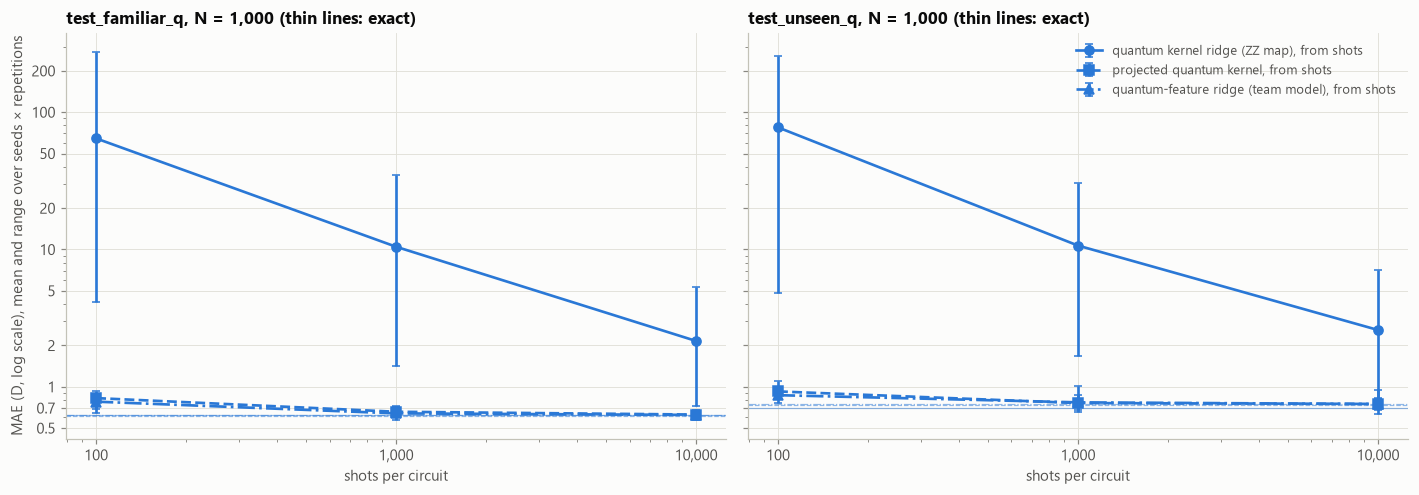

In [10]:
sh = shots.copy()
sh["shots"] = sh["shots"].astype(float)
st = sh.groupby(["eval_set", "model", "mode", "n_train", "shots"])["mae_D"].mean().unstack("shots")
st.columns = ["exact" if np.isinf(c) else f"{int(c):,} shots" for c in st.columns]
st = st.groupby(level=["eval_set", "model", "mode", "n_train"]).first()
st.index = st.index.set_levels([MODEL_LABELS[m] for m in st.index.levels[1]], level=1)
display(st.style.format("{:.3f}", na_rep="").set_caption("MAE (D) on the quantum test subsets, mean over seeds and repetitions"))
_ = save_result(st.reset_index(), f"{TAG}_shots_summary", out_dir=OUT_DIR, run=RUN,
                label="MAE vs shots, mean over seeds and repetitions; simulator only")

NS = max(SIZES)
END_TO_END = {"qkrr": "training and test kernels from shots", "pqk": "features from shots", "qridge": "features from shots"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, ev in zip(axes, Q_SETS):
    for m, mode in END_TO_END.items():
        s = sh[(sh["model"] == m) & (sh["eval_set"] == ev) & (sh["n_train"] == NS)]
        g = s[s["mode"] == mode].groupby("shots")["mae_D"].agg(["mean", "min", "max"])
        ax.errorbar(g.index, g["mean"], yerr=[g["mean"] - g["min"], g["max"] - g["mean"]], capsize=2.5,
                    label=f"{MODEL_LABELS[m]}, from shots", **model_style(m))
        ex = s[s["mode"] == "exact"]["mae_D"].mean()
        ax.axhline(ex, color=model_style(m)["color"], linestyle=model_style(m)["linestyle"], linewidth=0.8, alpha=0.5)
    ax.set(xscale="log", yscale="log", xlabel="shots per circuit", title=f"{ev}, N = {NS:,} (thin lines: exact)")
    ax.set_xticks([100, 1000, 10000], ["100", "1,000", "10,000"])
    ax.yaxis.set_major_locator(FixedLocator([0.5, 0.7, 1, 2, 5, 10, 20, 50, 100, 200]))
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:g}")
    ax.yaxis.set_minor_formatter(NullFormatter())
axes[0].set_ylabel("MAE (D, log scale), mean and range over seeds × repetitions")
axes[1].legend(fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_OUT / f"{TAG}_shots.png")
plt.show()

## 6. Hardware noise (FakeFez noise model on local Aer)

In [11]:
print(f"backend {meta_n['backend']}, {meta_n['shots']:,} shots, trained on S_({meta_n['seed']},{meta_n['n_train']}), "
      f"test molecules {meta_n['test_molecules']}; mean survival probability ⟨x|x⟩ under noise: {meta_n['survival_mean']:.3f}")
nt = noise.assign(model=lambda d: d["model"].map(MODEL_LABELS)).set_index(["model", "mode"])[["mae_D", "rmse_D", "r2", "bias_D"]]
display(nt.style.format("{:.3f}").set_caption("quantum test subsets (both), exact vs shots only vs noisy simulation"))

backend FakeFez, 1,000 shots, trained on S_(0,100), test molecules {'test_familiar_q': 30, 'test_unseen_q': 30}; mean survival probability ⟨x|x⟩ under noise: 0.730


## 7. Quantum cost of this comparison

Circuits and a rough lower bound on QPU time (circuits × shots × (circuit duration + readout + repetition delay)) to
train each quantum model and predict both test sets on IBM Heron hardware, at 1,000 shots per circuit. Circuit
durations come from the transpiled circuits of notebook `explore_07` (FakeFez).

In [12]:
cc = pd.read_csv(RESULTS_DIR / "explore07_circuit_costs.csv")
cc = cc[(cc["inputs k"] == 10) & (cc["encoding"] == "zz")].set_index("circuit")["duration (µs)"] * 1e-6
n_test = sum(meta_q["eval_sets"][k] for k in TEST)
SHOTS_COST = 1000
rows = []
for n in SIZES:
    for m, kind, d in (("qkrr", "fidelity", cc["overlap C(x, x′)"]), ("pqk", "projected", cc["U(x) + measure"]),
                       ("qridge", "z_readout", cc["U(x) + measure"])):
        train, pred = circuits_needed(kind, n, n_test)
        h = (qpu_seconds(train, SHOTS_COST, d) + qpu_seconds(pred, SHOTS_COST, d)) / 3600
        mae = sel(m, RED)
        mae = mae[(mae["n_train"] == n) & mae["eval_set"].isin(TEST)].groupby("eval_set")["mae_D"].mean()
        rows.append({"model": MODEL_LABELS[m], "N": n, "circuits": train + pred, "QPU hours": h,
                     "Open Plan months": h * 60 / 10, **{f"{ev} MAE": mae[ev] for ev in TEST}})
cost = pd.DataFrame(rows).set_index(["model", "N"])
display(cost.style.format({"circuits": "{:,}", "QPU hours": "{:,.2f}", "Open Plan months": "{:,.0f}",
                           **{f"{ev} MAE": "{:.3f}" for ev in TEST}})
        .set_caption(f"cost to train and predict {n_test:,} test molecules at {SHOTS_COST:,} shots per circuit"))

,,circuits,QPU hours,Open Plan months,test_familiar MAE,test_unseen MAE
model,N,,,,,
quantum kernel ridge (ZZ map),100,"2,235,150",160.63,964,0.735,0.689
projected quantum kernel,100,"67,206",4.78,29,0.724,0.681
quantum-feature ridge (team model),100,"22,402",1.59,10,0.731,0.699
quantum kernel ridge (ZZ map),300,"6,735,450",484.05,"2,904",0.578,0.525
projected quantum kernel,300,"67,806",4.83,29,0.578,0.527
quantum-feature ridge (team model),300,"22,602",1.61,10,0.597,0.556
quantum kernel ridge (ZZ map),1000,"22,801,500","1,638.67","9,832",0.492,0.437
projected quantum kernel,1000,"69,906",4.98,30,0.493,0.440
quantum-feature ridge (team model),1000,"23,302",1.66,10,0.545,0.493


## 8. Post-hoc runs: shot-aware quantum models

Changes made **after** seeing the run above, each logged as its own test run (CLAUDE.md rule 2). Run 1 showed the
fidelity-kernel model collapsing under finite shots: CV had tuned it on exact kernels and chose the smoothest
setting, whose kernel differences are smaller than the shot noise. Run 2 makes the quantum kernels **shot-aware**:
every kernel entry (fidelity kernel) or Bloch coordinate (projected kernel) is estimated from S shots in
cross-validation, in the final fit and in prediction, so CV picks the angle scale and penalty that work *with* the
noise (`quantum_kernel.ShotNoisyKernel`; α grid extended to 100 and 1000 for these models). Everything else is as
in run 1, and the models both runs share must give identical numbers.

run 2 (commit 89e6b62, after run 1, sections quantum): run 2 (post-hoc, after run 1): shot-aware quantum kernels (fidelity and projected), tuned, fit and evaluated with 100 / 1,000 / 10,000 shots per circuit; quantum section only; everything else as run 1
rows shared with run 1: 180, max |Δ MAE| = 0.0e+00 D


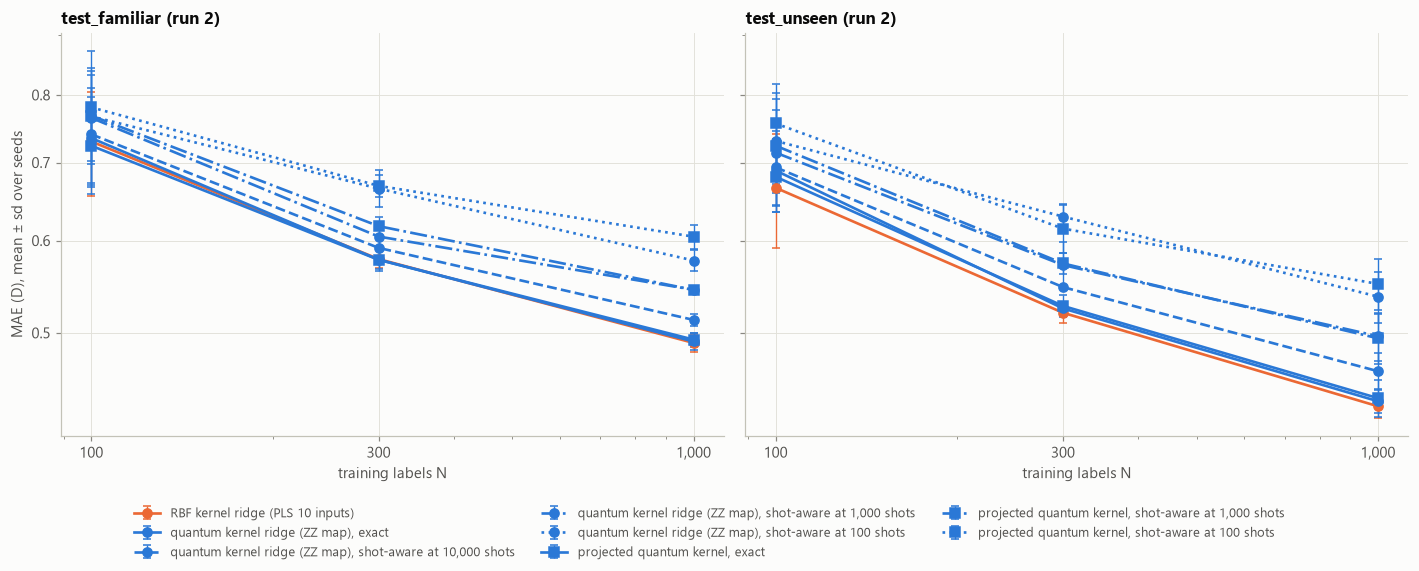

In [13]:
def qlabel(m):
    base, _, s = m.partition("@")
    return MODEL_LABELS[base] + (f", shot-aware at {int(s):,} shots" if s else (", exact" if base in QMODELS else ""))


SHOT_STYLE = {"": "-", "10000": "--", "1000": "-.", "100": ":"}
for r in LATER:
    info = runs.set_index("run").loc[r]
    q2 = pd.read_csv(SRC / f"test_run{r:02d}_quantum.csv")
    q2["inputs"] = q2["inputs"].fillna("—")
    print(f"run {r} (commit {str(info['commit'])[:7]}, after run {RUN}, sections {info['sections']}): {info['note']}")
    a, b = q2.set_index(keys)["mae_D"], quantum.set_index(keys)["mae_D"]
    common = a.index.intersection(b.index)
    print(f"rows shared with run {RUN}: {len(common)}, max |Δ MAE| = {(a.loc[common] - b.loc[common]).abs().max():.1e} D")

    # Same shot budget, two tunings: run 1 tuned on exact kernels (its shots section, end to end), run r with shots in CV.
    rows = []
    for base, mode in (("qkrr", "training and test kernels from shots"), ("pqk", "features from shots")):
        budgets = sorted(int(m.split("@")[1]) for m in q2["model"].unique() if m.startswith(base + "@"))
        for S in budgets:
            for ev in Q_SETS:
                for n in SIZES:
                    r1 = shots[(shots["model"] == base) & (shots["mode"] == mode) & (shots["shots"] == S)
                               & (shots["eval_set"] == ev) & (shots["n_train"] == n)]["mae_D"].mean()
                    pick = lambda m: q2[(q2["model"] == m) & (q2["inputs"] == RED) & (q2["eval_set"] == ev)
                                        & (q2["n_train"] == n)]["mae_D"].mean()
                    rows.append({"model": MODEL_LABELS[base], "shots": S, "eval_set": ev, "N": n, "exact": pick(base),
                                 f"run {RUN}: tuned exact, run at S shots": r1, f"run {r}: tuned with S shots": pick(f"{base}@{S}")})
    shot_aware = pd.DataFrame(rows)
    _ = save_result(shot_aware, f"test_run{r:02d}_shot_aware", out_dir=OUT_DIR, run=r, compared_with=RUN,
                    label="post-hoc run: shot-aware vs exact-tuned quantum kernels at the same shot budget; quantum test subsets")
    display(shot_aware.set_index(["model", "shots", "eval_set", "N"]).style.format("{:.3f}").set_caption(
        f"MAE (D) on the quantum test subsets, mean over seeds: the same shot budget, tuned for exact kernels (run {RUN}) "
        f"or with the shots in cross-validation (run {r})"))

    t = q2[q2["eval_set"].isin(TEST)].groupby(["model", "inputs", "eval_set", "n_train"])[["mae_D", "rmse_D"]].mean()
    t = t.unstack("n_train")
    t.index = pd.MultiIndex.from_tuples([(qlabel(m), i, ev) for m, i, ev in t.index], names=["model", "inputs", "eval_set"])
    display(t.style.format("{:.3f}").set_caption(f"run {r}: MAE and RMSE (D) on the test sets, mean over seeds"))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
    by_shots = lambda prefix: sorted((m for m in q2["model"].unique() if m.startswith(prefix)),
                                     key=lambda m: -int(m.split("@")[1]))
    order = ["rbf_krr", "qkrr", *by_shots("qkrr@"), "pqk", *by_shots("pqk@")]
    for ax, ev in zip(axes, TEST):
        for m in order:
            g = q2[(q2["model"] == m) & (q2["inputs"] == RED) & (q2["eval_set"] == ev)].groupby("n_train")["mae_D"]
            g = g.agg(["mean", "std"])
            if g.empty:
                continue
            st = model_style(m.partition("@")[0])
            st["linestyle"] = SHOT_STYLE[m.partition("@")[2]] if m.partition("@")[0] in QMODELS else st["linestyle"]
            ax.errorbar(g.index, g["mean"], yerr=g["std"].fillna(0), capsize=2.5, elinewidth=0.9,
                        label=qlabel(m) + (" (PLS 10 inputs)" if m == "rbf_krr" else ""), **st)
        ax.set(xscale="log", yscale="log", xlabel="training labels N", title=f"{ev} (run {r})")
        ax.yaxis.set_major_locator(FixedLocator([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.2]))
        ax.yaxis.set_major_formatter(lambda v, _: f"{v:g}")
        ax.yaxis.set_minor_formatter(NullFormatter())
        ax.set_xticks(SIZES, [f"{n:,}" for n in SIZES])
    axes[0].set_ylabel("MAE (D), mean ± sd over seeds")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=8.5, frameon=False)
    fig.tight_layout(rect=(0, 0.12, 1, 1))
    fig.savefig(FIG_OUT / f"test_run{r:02d}_shot_aware.png")
    plt.show()
if not LATER:
    print("no later runs")

## 9. On IBM quantum hardware

`scripts/hardware_run.py` measured the team's ⟨Z⟩ ridge on a real device: every training molecule of S_(0,100)
and 30 molecules from each quantum test subset (those of the noise section above) were encoded on 10 qubits and
measured in the Z basis, 1,000 shots each; the ridge readout was then refit on the device's numbers, on this computer.
The same circuits also ran locally on the device's noise model (a calibration snapshot of it, on Aer), so the
table compares, on identical molecules: exact simulation, an ideal device with the same shots, the simulated noise
of the same device, and the device itself. Each of these runs scores test molecules and is logged as a test run.

run 3: FakeQuebec (its noise model, local Aer), pqk, qridge, kernel, S_(0,100), 30 molecules per quantum test subset, 1,000 shots
run 4: ibm_quebec (IBM device, job db3da0kvf2bc73csuk60), qridge, S_(0,100), 30 molecules per quantum test subset, 1,000 shots


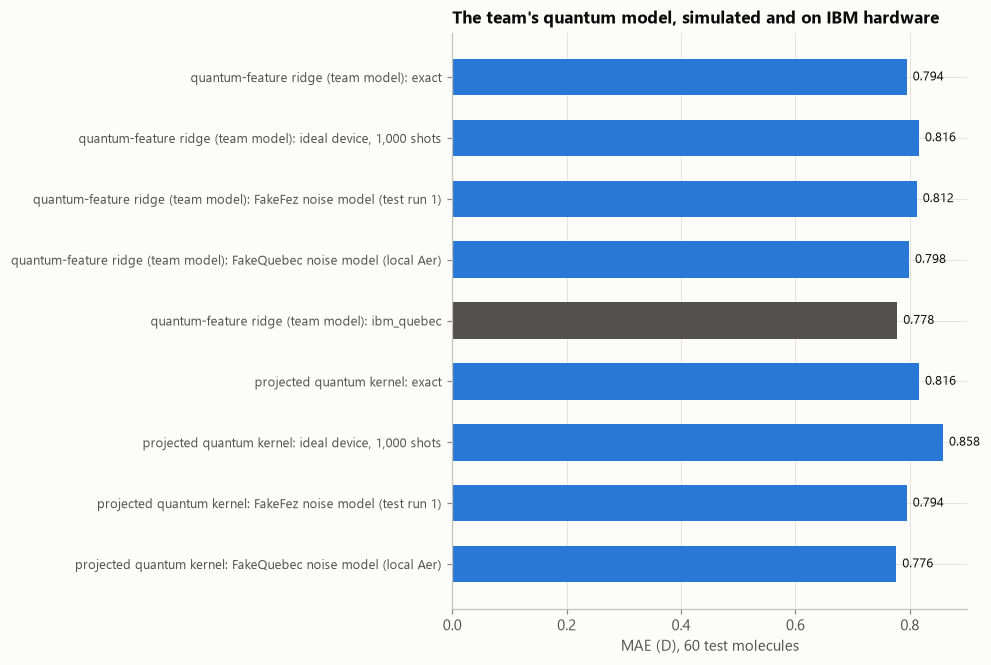

In [14]:
HW = sorted((RESULTS_DIR / "hardware").glob("*_scores.csv")) if not DRY else []
hw_rows = []
for path in HW:
    m = json.loads(path.with_name(path.name.replace(".csv", ".meta.json")).read_text())
    sc = pd.read_csv(path)
    print(f"run {m['run']}: {m['backend']} ({'IBM device, job ' + str(m['job_id']) if m['device'] else 'its noise model, local Aer'}), "
          f"{', '.join(m['parts'])}, S_({m['seed']},{m['n_train']}), {m['per_subset']} molecules per quantum test subset, "
          f"{m['shots']:,} shots")
    hw_rows.append(sc.assign(source=m["backend"], device=m["device"]))
if hw_rows:
    hwa = pd.concat(hw_rows, ignore_index=True).assign(on_device=lambda d: d["device"] & (d["mode"] == d["source"]))
    # exact and ideal-device rows are identical across these runs (same models, molecules and seed): keep one copy
    hwa = hwa.drop_duplicates(["model", "mode", "test_subset"])
    ref = noise.assign(test_subset="both", mode=lambda d: d["mode"].map({"noisy": "FakeFez noise model (test run 1)"}))
    ref = ref[ref["mode"].notna() & ref["model"].isin(hwa["model"].unique())].assign(on_device=False)
    allhw = pd.concat([hwa, ref], ignore_index=True)
    rank = lambda r: (0 if r["mode"] == "exact" else 1 if r["mode"].startswith("ideal") else 2 if "FakeFez" in r["mode"]
                      else 4 if r["on_device"] else 3)
    allhw = allhw.assign(_m=allhw["model"].map({"qridge": 0, "pqk": 1}), _r=allhw.apply(rank, axis=1))
    allhw = allhw.sort_values(["_m", "_r"]).drop(columns=["_m", "_r"])
    tab = allhw.pivot_table(index=["model", "mode"], columns="test_subset", values=["mae_D", "rmse_D"], sort=False)
    tab.index = tab.index.set_levels([MODEL_LABELS[x] for x in tab.index.levels[0]], level=0)
    display(tab.style.format("{:.3f}", na_rep="").set_caption(
        "MAE and RMSE (D) on the hardware test molecules: exact, ideal device, simulated device noise, real device"))
    both = allhw[allhw["test_subset"] == "both"]
    fig, ax = plt.subplots(figsize=(9, 0.55 * len(both) + 1.2))
    lab = [f"{MODEL_LABELS[a]}: {b}" for a, b in zip(both["model"], both["mode"])]
    ax.barh(range(len(both)), both["mae_D"], color=[INK_SECONDARY if d else model_style(mm)["color"]
                                                      for mm, d in zip(both["model"], both["on_device"])], height=0.6)
    for i, v in enumerate(both["mae_D"]):
        ax.annotate(f"{v:.3f}", (v, i), xytext=(4, 0), textcoords="offset points", va="center", fontsize=8.5)
    ax.set_yticks(range(len(both)), lab, fontsize=8.5)
    ax.invert_yaxis()
    ax.set(xlabel="MAE (D), 60 test molecules", title="The team's quantum model, simulated and on IBM hardware")
    fig.tight_layout()
    fig.savefig(FIG_OUT / "hardware_comparison.png")
    plt.show()
else:
    print("no hardware results yet")

## Summary

*Test run 1: the development settings, unchanged (commit `cc6fab3`); runs 2 (post-hoc), 3 and 4 (IBM hardware) below. Z and R only;
quantum models simulated locally unless marked. MAE in debye, mean over 3 seeds; mean baseline ≈ 1.14 D (familiar) and 1.25 D (unseen).*

1. **The run reproduces the development notebooks exactly.** All 464 development-set rows that notebooks 04 and 06
   also scored match to 0.0 D, so the test numbers belong to the models the team studied.
2. **The quantum models tie their classical twin.** At N = 1000 the headline quantum model (ZZ fidelity kernel,
   10 qubits, chosen by CV) scores **0.492 / 0.437 D** (test_familiar / test_unseen) against **0.490 / 0.433 D**
   for RBF kernel ridge on the same 10 PLS inputs; the paired difference is ≤ 0.005 D at N ≥ 300 (0.023 ± 0.030 D
   on test_unseen at N = 100). The no-entanglement control scores the same (0.490 / 0.433), as do the other
   encoders (RY + CZ, RY-RZ) and the projected kernel (0.493 / 0.440). The team's ⟨Z⟩ ridge is a little weaker
   (0.545 / 0.493).
3. **Classical models are better when they are not held to 10 inputs.** The best quantum-comparable classical model
   by CV, RBF kernel ridge on all 188 features, scores 0.453 / 0.420 D at N = 1000. Track A's latent-charge network
   scores 0.280 / 0.276 D at N = 1000 and **0.040 / 0.038 D with all 99,198 labels** (seed 0), 28× better than the
   mean baseline; below N ≈ 300 it is unstable and XGBoost or kernel ridge is the better choice.
4. **Geometry matters; composition alone does not get far.** Composition-only inputs give 0.94 / 0.81 D at N = 1000
   for every model, quantum and classical, against 0.49 / 0.44 D with geometry (PLS of all legal features).
5. **Unseen formulas were not harder on the test set.** Every model scores slightly better on test_unseen than on
   test_familiar (unseen/familiar ≈ 0.88–0.98), while on the development sets unseen formulas were much harder
   (0.73 vs 0.50 D for the quantum model). How hard "unseen" is depends on which formulas are held out: 93 test
   formulas versus 26 development ones.
6. **Finite shots break the fidelity-kernel model at N = 1000**, as on the development sets: with both kernels from
   1,000 shots per entry its MAE on the quantum test subsets is 10.5 / 10.7 D (exact: 0.62 / 0.70 D); 10,000 shots
   still give 2.2 / 2.6 D. CV picked the smoothest angle scale, whose kernel differences are below the shot noise.
   The projected kernel (0.66 / 0.76 D at 1,000 shots) and the ⟨Z⟩ ridge (0.64 / 0.77 D) degrade gracefully.
7. **Simulated hardware noise (FakeFez, N = 100, 60 test molecules) costs little:** 0.833 → 0.919 D for the
   fidelity kernel, 0.854 D after the depolarizing correction; the projected kernel and the ⟨Z⟩ ridge are within
   0.02 D of exact.
8. **Cost decides what can run on hardware.** Predicting the 22,302 test molecules at 1,000 shots needs 22.8 million
   circuits (≈ 1,600 QPU hours) for the fidelity-kernel model at N = 1000, 70,000 (≈ 5 h) for the projected kernel
   and 23,000 (≈ 1.7 h) for the ⟨Z⟩ ridge; IBM's Open Plan gives 10 minutes per 28 days.

9. **Run 2 (post-hoc): shot-aware tuning makes the fidelity kernel usable on a device.** With the shots inside
   cross-validation, CV picks a 10× larger ridge penalty (α = 1–10) and, at N = 1000 with 1,000 shots per circuit,
   the fidelity-kernel model scores **0.544 / 0.497 D** on the full test sets (exact: 0.492 / 0.437); on the quantum
   test subsets, 0.665 / 0.701 D against 10.5 / 10.7 D for the same shot budget tuned on exact kernels. 10,000 shots:
   0.513 / 0.464 D; 100 shots: 0.577 / 0.537 D. The shot-aware projected kernel matches it (0.544 / 0.495 D at 1,000
   shots). The 180 rows run 2 shares with run 1 are identical.
10. **Run 3: the hardware run rehearsed on ibm_quebec's noise model** (FakeQuebec on Aer, 60 test molecules, S_(0,100),
    1,000 shots): the ⟨Z⟩ ridge scores 0.798 D (exact 0.794) and the projected kernel 0.776 D (exact 0.816); raw
    fidelity-kernel entries are off by 0.31 on average (a state overlaps itself with probability 0.45 on this noise
    model), 0.034 after the depolarizing correction.
11. **Run 4: the team's ⟨Z⟩ ridge on IBM's `ibm_quebec`** (job `db3da0kvf2bc73csuk60`: 160 circuits × 1,000 shots,
    45 s of QPU time charged, ≈ 85 min in the queue). Trained on the device's measurements of S_(0,100) and scored on
    the device's measurements of the 60 test molecules, it reaches **0.778 D** (0.792 familiar, 0.764 unseen) against
    0.794 D exact, 0.816 D for an ideal device with the same shots and 0.798 D on the device's noise model. With 60
    test molecules these differences are within sampling error: on real hardware, the model works as well as in
    perfect simulation, because its ridge readout is refit on the device's own (noisy) features.

**Conclusion.** On these inputs the quantum kernels behave like a classical RBF kernel: as accurate as their classical
twin, no more, and the best classical models are far more accurate with more data (0.040 D with all labels). Run as
on a device, the fidelity kernel is only usable when tuned with the shot noise in the loop (run 2, post-hoc), and
then it costs ≈ 0.05 D at 1,000 shots; the feature-based quantum models (projected kernel, ⟨Z⟩ ridge) need 1–3
circuits per molecule instead of one per pair, tolerate shots and noise, and are the ones that fit a QPU budget;
the ⟨Z⟩ ridge ran on IBM hardware with no loss of accuracy.